<a href="https://www.kaggle.com/code/mohammednafayali/relationship-dynamics-shap-interpretability?scriptVersionId=342711276" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/data_dictionary.csv
/kaggle/input/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/marriage_longevity_master.csv


### 1. Data Ingestion & Dictionary Inspection

In this step, we import the raw dataset files and inspect both the metadata schema (`df2`) and sample records (`df`).

* **Data Dictionary Loading:** Read `data_dictionary.csv` to map feature names, data types, and underlying domain descriptions.
* **Master Dataset Loading:** Load `marriage_longevity_master.csv` containing 45,000 observations and 24 attributes.
* **Initial Inspection:** Display dataframe previews to verify schema alignment across demographical, behavioral (Gottman metrics), and target (`divorced`) columns.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/marriage_longevity_master.csv")
df2=pd.read_csv("/kaggle/input/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/data_dictionary.csv")
df2

,column,type,description
0,marriage_id,string,Unique marriage id
1,marriage_number,int,"1st, 2nd or 3rd marriage — one of the stronges..."
2,age_at_marriage,int,Age at the start of this marriage
3,age_gap_years,int,Age difference between partners
4,education_level,string,less_than_hs / high_school / some_college / ba...
5,household_income_usd,float,Household income (USD)
6,financial_stress,float,Self-reported financial stress (0-10)
7,both_employed,int,1 if both partners employed
8,cohabited_before,int,1 if the couple cohabited before marrying
9,premarital_counseling,int,1 if they did premarital counselling — a prote...


In [3]:
df

,marriage_id,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
0,MAR000000,1,36,6,less_than_hs,68600.0,5.9,1,1,0,...,7.7,5.8,8.1,4.1,2.22,3.0,4.0,22.0,NaN,0
1,MAR000001,2,59,1,some_college,328800.0,0.0,1,1,0,...,1.7,6.8,3.0,5.1,11.99,1.0,1.0,15.5,NaN,0
2,MAR000002,2,44,1,high_school,139900.0,6.1,0,0,1,...,6.5,4.2,4.8,5.7,2.27,4.0,2.0,7.2,NaN,0
3,MAR000003,1,25,2,bachelors,97600.0,5.9,1,1,1,...,0.0,4.1,0.9,8.7,6.24,0.0,4.0,13.5,NaN,0
4,MAR000004,2,29,3,graduate,98200.0,4.0,0,0,1,...,4.4,4.6,9.6,8.9,2.59,4.0,5.0,7.5,7.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,MAR044995,2,45,3,high_school,145300.0,7.0,1,1,0,...,8.5,7.1,2.1,6.4,3.16,2.0,3.0,1.8,NaN,0
44996,MAR044996,1,33,0,some_college,95600.0,8.9,0,1,0,...,3.9,5.0,8.1,6.7,1.96,4.0,0.0,2.2,NaN,0
44997,MAR044997,1,33,3,some_college,91200.0,4.9,1,0,0,...,1.4,1.5,6.5,7.0,2.33,5.0,0.0,7.8,7.8,1
44998,MAR044998,1,30,5,some_college,21300.0,9.5,0,1,1,...,7.6,4.7,9.1,1.5,4.95,1.0,5.0,9.1,9.1,1


### 2. Exploratory Data Analysis & Quality Audit

In this stage, we assess overall missing value counts, dataset dimensions, and statistical distributions to spot anomalies and potential data leakage.

* **Missing Value Check:** All predictors are fully populated with 0 missing values, except for `years_to_divorce` ($24,292$ missing entries), which corresponds exactly to couples who remain married ($45,000 - 20,708 = 24,292$).
* **Statistical Metrics:** `display(df.describe())` verifies feature scales and summary statistics across behavioral indicators (Gottman scores), demographic factors, and target distributions.
* **Library Setup:** Import scikit-learn preprocessing modules, LightGBM, Seaborn, Matplotlib, and SHAP for downstream modeling and interpretability.

In [4]:
# Check missing values
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
display(df.describe())

print(f"\nShape: {df.shape[0]} Rows and {df.shape[1]} Columns")


--- Missing Values ---
marriage_id                      0
marriage_number                  0
age_at_marriage                  0
age_gap_years                    0
education_level                  0
household_income_usd             0
financial_stress                 0
both_employed                    0
cohabited_before                 0
premarital_counseling            0
child_before_marriage            0
n_children                       0
religious_attendance             0
criticism                        0
contempt                         0
defensiveness                    0
stonewalling                     0
repair_attempt_success           0
positive_negative_ratio          0
conflict_frequency_weekly        0
shared_activities_weekly         0
years_married                    0
years_to_divorce             24292
divorced                         0
dtype: int64

--- Summary Statistics ---


,marriage_number,age_at_marriage,age_gap_years,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,n_children,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,...,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,20708.000000,45000.000000
mean,1.302244,30.168644,2.868156,118024.922222,5.186407,0.658667,0.618178,0.243822,0.189644,1.404733,...,3.256393,4.760267,3.801571,5.628598,4.011752,2.378267,3.035089,10.699487,7.721021,0.460178
std,0.560842,7.588164,2.205134,83738.454555,2.357498,0.474162,0.485839,0.429391,0.392024,1.183376,...,2.181556,2.154957,2.169450,2.284411,2.852853,1.656582,1.920517,7.820057,4.848361,0.498417
min,1.000000,16.000000,0.000000,9000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.500000,0.500000,0.000000
25%,1.000000,25.000000,1.000000,61800.000000,3.600000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.600000,3.300000,2.200000,4.000000,2.080000,1.000000,2.000000,5.100000,4.200000,0.000000
50%,1.000000,29.000000,2.000000,95700.000000,5.200000,1.000000,1.000000,0.000000,0.000000,1.000000,...,3.200000,4.800000,3.800000,5.700000,3.260000,2.000000,3.000000,8.700000,6.700000,0.000000
75%,2.000000,34.000000,4.000000,148400.000000,6.800000,1.000000,1.000000,0.000000,0.000000,2.000000,...,4.800000,6.200000,5.300000,7.300000,5.060000,3.000000,4.000000,14.000000,10.200000,1.000000
max,3.000000,68.000000,16.000000,600000.000000,10.000000,1.000000,1.000000,1.000000,1.000000,6.000000,...,10.000000,10.000000,10.000000,10.000000,20.000000,12.000000,15.000000,55.000000,45.000000,1.000000



Shape: 45000 Rows and 24 Columns


### 3. Feature Isolation, Encoding & Machine Learning Pipeline Construction

In this step, we eliminate target leakage, isolate baseline predictive features, and construct a production-ready scikit-learn pipeline.

* **Target Leakage & Metadata Removal:** Drop `marriage_id` (non-predictive identifier) along with `years_to_divorce` and `years_married` (direct target leakage variables) to isolate features known prior to outcome determination.
* **Stratified Data Splitting:** Partition data into training ($80\%$) and testing ($20\%$) subsets, maintaining target class proportions (`stratify=y`).
* **Categorical Feature Preprocessing:**
  * `OrdinalEncoder`: Preserves natural rank order for `education_level` (`less_than_hs` < `high_school` < `some_college` < `bachelors` < `graduate`).
  * `OneHotEncoder`: Encodes nominal attributes (`religious_attendance`), dropping the first dummy category to prevent multicollinearity.
* **Pipeline Integration:** Combine `ColumnTransformer` and a regularized `LGBMClassifier` (`n_estimators=100`, `learning_rate=0.05`, `max_depth=5`) into a single end-to-end execution pipeline to completely eliminate preprocessing data leakage.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,classification_report,ConfusionMatrixDisplay,precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import shap
import matplotlib.pyplot as plt

In [6]:
# We are going to drop non-predictive metadata and target leakage variables
X = df.drop(columns=["marriage_id", "years_to_divorce", "years_married", "divorced"])
y = df["divorced"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Encoding features
education_order = ["less_than_hs", "high_school", "some_college", "bachelors", "graduate"]
ordinal_cols = ["education_level"]
nominal_cols = ["religious_attendance"]

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=[education_order]), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", sparse_output=False), nominal_cols)
],remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")


model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(n_estimators=100,learning_rate=0.05,max_depth=5,random_state=42,verbose=-1))
])

model_pipeline.fit(X_train, y_train)

print("Pipeline successfully fitted without data leakage!")


Pipeline successfully fitted without data leakage!


### 4. Model Evaluation & Overfitting Assessment

Here, we evaluate the trained LightGBM model on both training and held-out test sets to check generalization performance and verify that the model has not overfitted.

* **Probability Predictions:** Extract class probabilities (`predict_proba`) across train and test sets to compute ranking performance metrics.
* **Generalization Check (ROC-AUC):** 
  * Train ROC-AUC: **0.8548**
  * Test ROC-AUC: **0.8333**
  * The minimal $0.0215$ gap confirms strong generalization with no signs of overfitting.
* **Classification Performance:** Evaluate test set precision, recall, and F1-scores across classes. The model achieves balanced precision ($0.75$) and recall ($0.71$) on the positive class (`divorced`), yielding a solid overall macro average F1-score of **0.75**.

In [7]:
y_train_pred = model_pipeline.predict_proba(X_train)[:, 1]
y_test_pred = model_pipeline.predict_proba(X_test)[:, 1]


train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")

y_test_class = model_pipeline.predict(X_test)
print("\n--- Test Set Classification Report ---")
print(classification_report(y_test, y_test_class))


Train ROC-AUC: 0.8548
Test ROC-AUC:  0.8333

--- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.79      0.78      4858
           1       0.75      0.71      0.73      4142

    accuracy                           0.75      9000
   macro avg       0.75      0.75      0.75      9000
weighted avg       0.75      0.75      0.75      9000



### 5. Global Model Interpretability with TreeSHAP

In this step, we extract the transformed test set features and fitted LightGBM estimator to compute TreeSHAP values, providing global explainability for the model's predictions.

---

#### **How to Interpret a SHAP Summary Plot**
* **Feature Ordering (Y-Axis):** Features are ranked vertically from top to bottom based on their overall impact on the model's decisions (global feature importance).
* **Feature Value (Color Bar):** Each dot represents a single couple in the test dataset. **Magenta/Red** indicates a high value for that feature, while **Blue** indicates a low value.
* **Impact on Prediction (X-Axis):** The horizontal position shows the feature's effect on log-odds:
  * **Positive SHAP values (Right of 0.0):** Pushes the model toward predicting **Divorce (`1`)**.
  * **Negative SHAP values (Left of 0.0):** Pushes the model toward predicting **Not Divorced (`0`)**.

---

#### **Key Insights & Psychological Findings**

1. **The Four Horsemen Drive Risk:**
   * **`contempt`:** Positioned as the single most influential variable. High levels of contempt (bright red cluster far to the right) drastically increase the predicted log-odds of divorce ($+0.5$ to $+1.2$).
   * **`criticism` & `defensiveness`:** Show similar right-skewed distributions where elevated levels consistently drive higher divorce predictions.

2. **Relationship Buffers & De-escalation:**
   * **`repair_attempt_success` & `positive_negative_ratio`:** High scores (red points) cluster heavily on the negative side of the plot (SHAP values between $-0.2$ and $-0.6$). This proves that effective de-escalation tactics and higher positive interaction ratios act as strong protective buffers against marital dissolution.

3. **Sociodemographic Dynamics:**
   * **`marriage_number`:** Higher order marriages (second or third, shown in red) create a distinct positive tail to the right, driving up divorce risk.
   * **`education_level`:** Demonstrates an inverse relationship—higher educational attainment (red) pulls predictions toward the non-divorce side (left), while lower levels (blue) increase risk.

4. **Low-Impact Predictors:**
   * Categorical indicators like `religious_attendance_weekly` and `cohabited_before` cluster tightly around $0.0$, revealing that lifestyle background variables carry far less predictive weight compared to active interpersonal interaction dynamics.

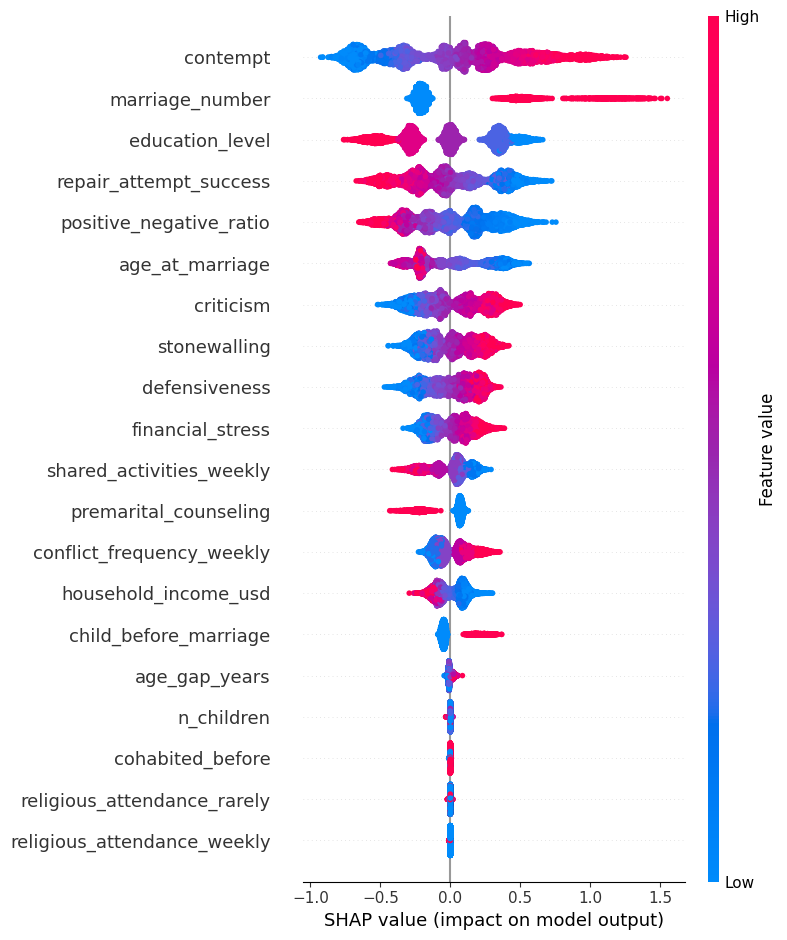

In [8]:
# 1. Transform test features directly into a pandas DataFrame
preprocessed_X_test = model_pipeline.named_steps["preprocessor"].transform(X_test)
fitted_classifier = model_pipeline.named_steps["classifier"]

# 2. Compute TreeSHAP
explainer = shap.TreeExplainer(fitted_classifier)
shap_values = explainer(preprocessed_X_test)

# 3. Plot Global SHAP Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, preprocessed_X_test)


### 6. Classification Error Analysis & Local Instance Explanation

In this step, we evaluate the model's classification matrix across actual classes and break down a single prediction using a SHAP Waterfall plot.

---

#### **1. Confusion Matrix Analysis**
* **True Negatives ($3,861$):** Married couples correctly predicted as remaining married.
* **True Positives ($2,929$):** Divorced couples correctly predicted as divorced.
* **False Positives ($997$):** Married couples incorrectly flagged as high divorce risk (Type I error).
* **False Negatives ($1,213$):** Divorced couples incorrectly predicted as remaining married (Type II error).
* **Takeaway:** The model demonstrates strong overall accuracy ($\approx 75.4\%$) with a balanced error distribution across both classes on unseen test data.

---

#### **2. Local Instance Explanation (Waterfall Plot for Sample #0)**
The waterfall plot shows how individual feature values move the prediction away from the baseline expected value $E[f(X)] = -0.209$:

* **Base Expected Log-Odds ($E[f(X)] = -0.209$):** The average prediction across the entire training dataset prior to evaluating sample #0.
* **Risk Factors (Red Arrows):**
  * High `criticism` ($6.7$) adds **$+0.39$** log-odds toward divorce.
  * Elevated `contempt` ($4.6$) adds **$+0.32$** log-odds toward divorce.
  * Presence of `child_before_marriage` ($1$) adds **$+0.21$** log-odds.
* **Protective Factors (Blue Arrows):**
  * Older `age_at_marriage` ($39$ years) subtracts **$-0.35$** log-odds.
  * Higher `education_level` ($3$, Bachelor's) subtracts **$-0.29$** log-odds.
  * First marriage (`marriage_number = 1`) subtracts **$-0.24$** log-odds.
  * High `repair_attempt_success` ($6.7$) subtracts **$-0.23$** log-odds.
  * Remaining 13 features collectively reduce the log-odds by **$-0.31$**.
* **Final Model Output ($f(x) = -1.121$):** The protective factors outweigh the risk drivers, pulling the final output significantly below zero to accurately classify sample #0 as **Not Divorced (`0`)**.

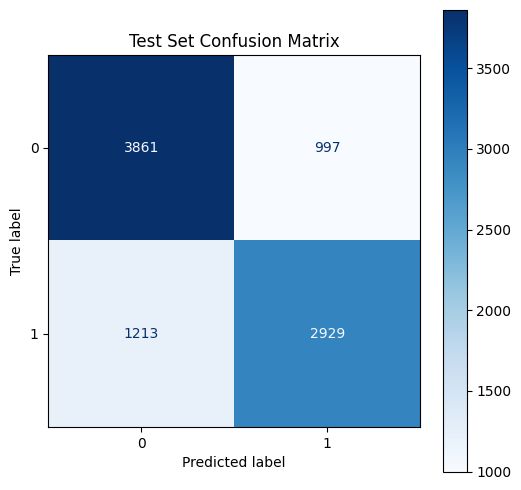

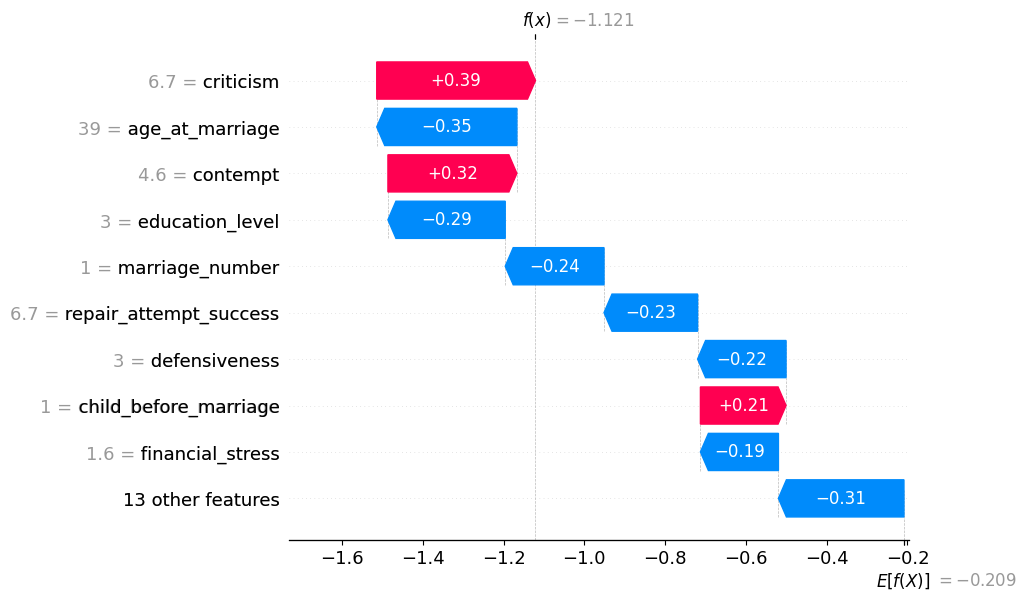

In [9]:
fig,ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model_pipeline,X_test,y_test,cmap="Blues",ax=ax)
plt.title("Test Set Confusion Matrix")
plt.show()

# Individual Prediction Explanation (Waterfall Plot for First Test Sample)
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0])


### 7. Feature Interaction & Non-Linear Dependence Analysis

In this final step, we generate a SHAP Dependence Plot for `education_level` to analyze non-linear relationships, threshold effects, and feature interaction dynamics with `positive_negative_ratio`.

---

#### **1. How to Read a SHAP Dependence Plot**
* **X-Axis (`education_level`):** Represents the ordinal feature levels ($0$: `less_than_hs`, $1$: `high_school`, $2$: `some_college`, $3$: `bachelors`, $4$: `graduate`).
* **Y-Axis (SHAP Value):** The direction and magnitude of the feature's impact on predicting divorce ($> 0.0$ increases risk, $< 0.0$ decreases risk).
* **Color Scale (`positive_negative_ratio`):** Shows interaction effects with a secondary feature. **Magenta/Red** represents high interaction scores, while **Blue** represents low scores.

---

#### **2. Key Findings & Domain Insights**

* **Monotonic Protective Effect:** As `education_level` increases from $0$ to $4$, the SHAP values drop consistently from **$+0.5$** down to **$-0.6$**, demonstrating that higher education acts as a steady protective factor against divorce.
* **Tipping Point at Level 2:** 
  * At levels $0$ and $1$, SHAP values sit strictly above $0.0$, pushing model predictions toward higher risk.
  * At level $2$ (`some_college`), the impact crosses the baseline threshold ($0.0$).
  * At levels $3$ and $4$, SHAP values remain entirely negative, steadily pulling predictions toward non-divorce.
* **Secondary Interaction with Interaction Ratio:** Across all education tiers, couples with higher positive-to-negative interaction ratios (red/magenta points) cluster at the lower bound of each vertical column, proving that positive behavioral dynamics provide an additional protective effect across all educational levels.

<Figure size 800x500 with 0 Axes>

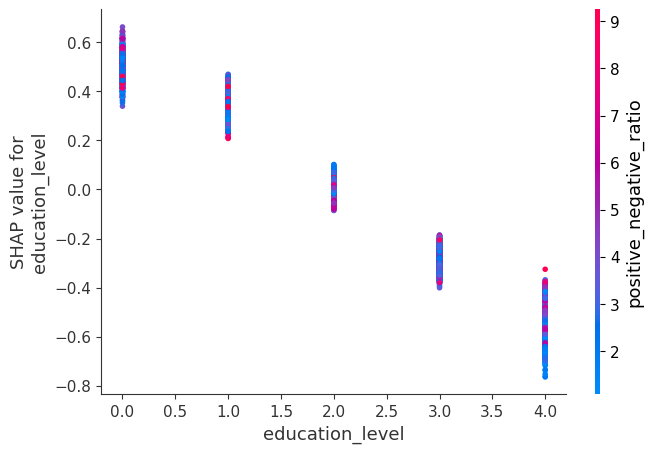

In [10]:
# SHAP Dependence plot for education_level
plt.figure(figsize=(8, 5))
shap.dependence_plot("education_level", shap_values.values, preprocessed_X_test)

In [11]:
import joblib

# 1. Save the fitted model pipeline
joblib.dump(model_pipeline, "model_pipeline.pkl")

# 2. Save preprocessed test data for local interpretability in Streamlit
preprocessed_X_test.to_csv("preprocessed_X_test.csv", index=False)

print("Artifacts successfully exported: 'model_pipeline.pkl' and 'preprocessed_X_test.csv'")


Artifacts successfully exported: 'model_pipeline.pkl' and 'preprocessed_X_test.csv'
